Problem statement:

For a safe and secure lending experience, it's important to analyze the past data. In this project, you have to build a deep learning model to predict the chance of default for future loans using historical data. As you will see, this dataset is highly imbalanced and includes a lot of features that make this problem more challenging.

Objective: Create a model that predicts whether or not an applicant will be able to repay a loan using historical data

### 1.EDA

## 1.1.Create at minumum 3 graphs and Decribe the information learned from the generated charts

In [1]:
# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import accuracy_score,classification_report, roc_auc_score, roc_curve,confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler,PolynomialFeatures
from sklearn.compose import ColumnTransformer


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #.  It is a platform and programming model created by NVIDIA that allows software (like PyTorch) to use the GPU 
                                                                      #   for general-purpose computation — not just graphics.In short:CUDA = using the GPU to do math fast
print(f'Using device: {device}')

Using device: cpu


In [2]:
pd.set_option('display.max_columns', None) # Tell pandas not to truncate the output.
df = pd.read_csv('../data/Home_Loan.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
pd.set_option('display.max_colwidth', None) # this will let the max wide so i can see all description
df_dic = pd.read_csv('../data/Home_Loan_Dictionary.csv', encoding="latin1")
df_dic.head()

,Column no.,Variable Name,Description
0,1,SK_ID_CURR,Unique identifier for each client.
1,2,TARGET,"Whether the loan was repaid (1 for yes, 0 for no)."
2,3,NAME_CONTRACT_TYPE,"Type of loan contract (e.g., Cash loans, Revolving loans)."
3,4,CODE_GENDER,Gender of the applicant.
4,5,FLAG_OWN_CAR,Whether the applicant owns a car (Yes/No).


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [7]:
for col in df.columns:
    print(col)

SK_ID_CURR
TARGET
NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
CNT_CHILDREN
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AMT_GOODS_PRICE
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
REGION_POPULATION_RELATIVE
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_REGISTRATION
DAYS_ID_PUBLISH
OWN_CAR_AGE
FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
FLAG_EMAIL
OCCUPATION_TYPE
CNT_FAM_MEMBERS
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
WEEKDAY_APPR_PROCESS_START
HOUR_APPR_PROCESS_START
REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
ORGANIZATION_TYPE
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
APARTMENTS_AVG
BASEMENTAREA_AVG
YEARS_BEGINEXPLUATATION_AVG
YEARS_BUILD_AVG
COMMONAREA_AVG
ELEVATORS_AVG
ENTRANCES_AVG
FLOORSMAX_AVG
FLOORSMIN_AVG
LANDAREA_AVG
LIVINGAPARTMENTS_AVG
LIVINGAREA_AVG
NONLIVINGAPARTMENTS_AVG
NONLIVINGAREA_AVG
APART

In [8]:
df.shape

(307511, 122)

In [9]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

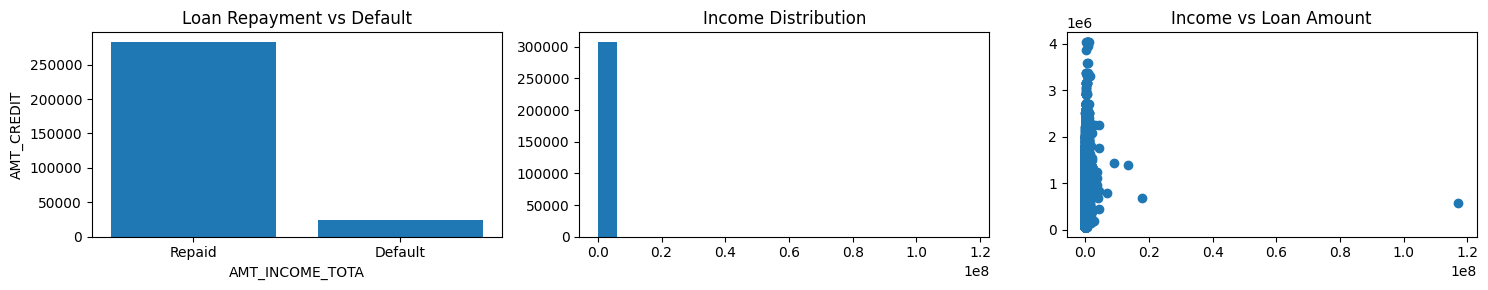

In [10]:
fig, ax = plt.subplots(1,3 , figsize =(15,3))

counts = df['TARGET'].value_counts()

ax[0].bar(['Repaid', 'Default'], counts)
ax[0].set_title("Loan Repayment vs Default")
ax[0].set_xlabel("Loan Status")
ax[0].set_ylabel("Number of Applicants")

# Graph 2
ax[1].hist(df['AMT_INCOME_TOTAL'], bins=20)
ax[1].set_title("Income Distribution")

# Graph 3
ax[2].scatter(df['AMT_INCOME_TOTAL'], df['AMT_CREDIT'])
ax[2].set_title("Income vs Loan Amount")
ax[0].set_xlabel("AMT_INCOME_TOTA")
ax[0].set_ylabel("AMT_CREDIT")

plt.tight_layout()

plt.show()

#### Describe the information learned from the generated charts 

1 - The first chart shows that most borrowers successfully repaid their loans, while a smaller portion defaulted. 
This indicates that the dataset is imbalanced, with significantly more successful repayments than defaults.


2 - The second chart shows the distribution of applicant income. Most applicants fall within lower to moderate income ranges.
 The large single bar appears because the dataset contains extreme income values (outliers), which compress most observations into the same range

3 - Most applicants have lower incomes and request similar loan amounts. The plot does not show a strong relationship between income and loan size.

### 2.Non-Feature Engineered Modeling for Baseline Performance

### 2.1.NOTE: you might have to perform some basic feature engineering / data wrangling in-order to train your baseline models. 
Ensure you document what / if any modifications to the dataset you perform

In [11]:
df.isna().sum()[df.isna().sum() > 1]

AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 66, dtype: int64

In [12]:
df = df.fillna(0)
df.isna().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 122, dtype: int64

In [13]:
df.select_dtypes(include='object').columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [14]:
# removing the id columns because it dosen't have any valuable info
df = df.drop(columns=['SK_ID_CURR'])

In [15]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

In [16]:
X = pd.get_dummies(X)

### 2.2.Machine Learning Model
Choose, Justify, and Train a traditional Machine learning algorithm from scikit-learn to predict the TARGET feature.

In [17]:
X_train, X_test, y_train, y_test_1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [19]:
# predicted classes
y_pred = model.predict(X_test)

# predicted probabilities
y_pred_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test_1, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9194836024258979


In [20]:
roc_auc = roc_auc_score(y_test_1, y_pred)
print("ROC-AUC for ML:", roc_auc)

ROC-AUC for ML: 0.49997347667715814


In [21]:
print("classification_report for ML")
print(classification_report(y_test_1, y_pred))

classification_report for ML
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.00      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



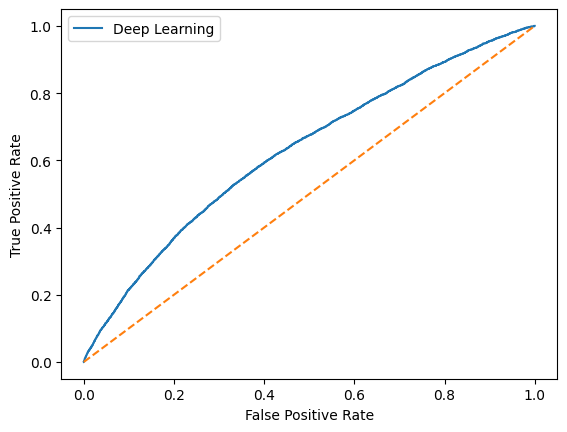

In [ ]:

fpr, tpr, _ = roc_curve(y_test_1, y_pred_prob)

plt.plot(fpr, tpr, label="ML Learning")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### 2.3.Deep Learning Model
Train a custom Deep learning model to get predictions
Justify your model architecture choices.
Compare the performance of the machine learning and deep learning models trained on the non-feature engineered data

In [23]:
df2 = df.copy()

In [24]:
df2['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [25]:

X = df2.drop(columns=["TARGET"])
y = df2["TARGET"]

X = pd.get_dummies(X, drop_first=False)

X = X.fillna(0)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
# Scale features (recommended for DL)
scaler = StandardScaler(with_mean=False)  # with_mean=False is safe for sparse-like one-hot matrices
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [27]:
X_train_s.shape

(246008, 250)

In [ ]:
# Your dataset:
# class 0 (repaid):  92% → ~226,000 rows
# class 1 (default):  8% → ~20,000 rows

# =================Without weights:=============================================
# model sees 92% zeros → just predicts 0 every time
# → 92% accuracy but catches NO defaults! 

# What compute_class_weight('balanced') Does
# Formula:
# weight = total_samples / (n_classes × samples_in_class)

# ========================================================
# For class 0:
# weight_0 = 246000 / (2 × 226000) = 0.54

#  For class 1:
# weight_1 = 246000 / (2 × 20000) = 6.15

# weight_dict = {0: 0.54, 1: 6.15}

# ===========================================================
# What These Weights Mean

# During training, every mistake is multiplied by weight:

# Getting class 0 wrong:
# loss × 0.54  -->  penalty REDUCED ← majority class 

# Getting class 1 wrong:
# loss × 6.15  -->  penalty INCREASED 6x ← minority class 

# Model learns:
# "missing a default is 11x more costly than missing a repayment"
# → tries much harder to catch defaults 


## ================Simple Analogy======================

# Without weights:
# Teacher grades 100 questions
# → 92 easy questions (class 0)
# → 8 hard questions (class 1)
# → student ignores hard ones, still gets 92% 

# With weights:
# → each hard question worth 6 points
# → each easy question worth 0.5 points
# → student MUST learn hard questions to pass! 


# =====================Bottom Line ======================================

# weight_dict = {0: 0.54, 1: 6.15}

# Class 0 mistakes → small penalty  (common, less important)
# Class 1 mistakes → big penalty    (rare, very important!)

# Model is FORCED to pay attention to minority class 





In [28]:
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])
# Compute weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train), class_weights))

# zip() --> pairs two lits together --> classes = [0,1] , weights =[0.54, 6.17], output --> [(0, 0.54), (1, 6.17)] , it pairs each class with its weight
# dict() --> converts those pairs into a dictionary --> dict(zip(classes, weights)) --> {0: 0.54, 1:6.17} --> Keras expects this format

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=5, restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=20,
    class_weight= weight_dict,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


2026-03-07 15:20:42.706769: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 196806000 exceeds 10% of free system memory.


Epoch 1/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - auc: 0.6783 - loss: 0.6558 - val_auc: 0.7208 - val_loss: 2.2970
Epoch 2/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - auc: 0.7135 - loss: 0.6207 - val_auc: 0.7252 - val_loss: 0.9619
Epoch 3/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - auc: 0.7210 - loss: 0.6146 - val_auc: 0.7302 - val_loss: 0.6758
Epoch 4/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - auc: 0.7234 - loss: 0.6129 - val_auc: 0.7280 - val_loss: 0.6989
Epoch 5/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - auc: 0.7247 - loss: 0.6117 - val_auc: 0.7312 - val_loss: 0.5671
Epoch 6/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - auc: 0.7276 - loss: 0.6094 - val_auc: 0.7294 - val_loss: 0.6198
Epoch 7/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - auc: 0.7300 - loss: 0.6075 - val_auc: 0.7320 - val_loss: 0.5403
Epoch 8/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - auc: 0.7320 - loss: 0.6061 - val_auc: 0.7316 - val_loss: 0.5464
Epoch 9/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 1

In [29]:
# Dense(1, activation='sigmoid') --> (n_samples, 1) examples, [[0.12],[0.85],[0.33]] ,But sklearn metrics expect:(0.12, 0.85, 0.33) 
# So i should convert it --> pred = model.predict(X_test_s).ravel(), "ravel()"-->This is just formatting the output for evaluation.
y_pred_p = model.predict(X_test_s).ravel() 
y_pred = (y_pred_p > 0.5).astype(int) # evaluate accuracy or classification report we convert probabilities to 0 or 1:

1922/1922 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [30]:
print(classification_report(y_test, y_pred ))

              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.16      0.63      0.25      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.67      0.53     61503
weighted avg       0.89      0.70      0.77     61503



In [31]:
roc_auc = roc_auc_score(y_test, y_pred_p)
print("ROC-AUC for DL:",roc_auc )

ROC-AUC for DL: 0.7308305668776914


In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_p)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

Best threshold: 0.47473526


### 2.3.2.Justify your model architecture choices.
The model uses a fully connected neural network because the input data is tabular and the task is binary classification. Dense layers help capture non-linear relationships between features, while ReLU activation improves learning efficiency. Dropout was added to reduce overfitting, and a sigmoid output layer was used to produce a probability for the two target classes.

## 2.4.Compare the performance of the machine learning and deep learning models trained on the non-feature engineered data

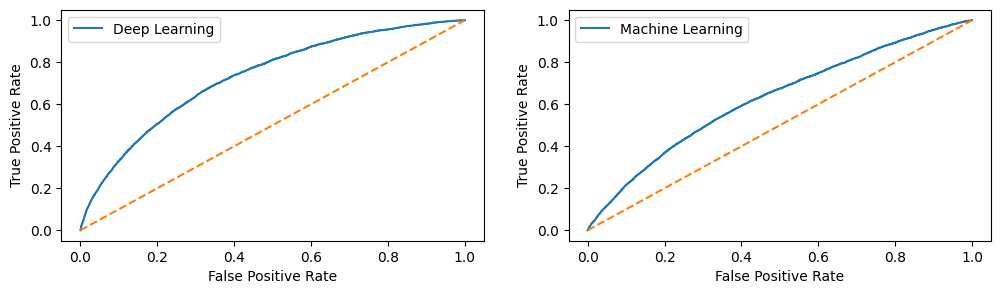

In [33]:
fig, ax = plt.subplots(1,2 , figsize =(12,3))

fpr, tpr, _ = roc_curve(y_test, y_pred_p)

ax[0].plot(fpr, tpr, label="Deep Learning")
ax[0].plot([0,1],[0,1],'--')
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()


fpr, tpr, _ = roc_curve(y_test_1, y_pred_prob)

ax[1].plot(fpr, tpr, label="Machine Learning")
ax[1].plot([0,1],[0,1],'--')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")

plt.legend()
plt.show()

# Deep learning model separates classes better, it goes left up faster than ML

In [34]:
# ROC-AUC measures how well a model separates the two classes (repaid vs default).
roc_auc = roc_auc_score(y_test, y_pred_p)
print("ROC-AUC for DL:",roc_auc )

ROC-AUC for DL: 0.7308305668776914


In [35]:
roc_auc = roc_auc_score(y_test_1, y_pred)
print("ROC-AUC for ML:", roc_auc)

ROC-AUC for ML: 0.503027937335544


In [36]:
print("classification_report for DL")
print(classification_report(y_test, y_pred ))

classification_report for DL
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.16      0.63      0.25      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.67      0.53     61503
weighted avg       0.89      0.70      0.77     61503



In [37]:
print("classification_report for ML")
print(classification_report(y_test_1, y_pred))

classification_report for ML
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     56554
           1       0.08      0.32      0.13      4949

    accuracy                           0.65     61503
   macro avg       0.50      0.50      0.46     61503
weighted avg       0.85      0.65      0.73     61503



### 3.Feature Engineered Data Modeling

### 3.1.Complete step 2 again but with a feature engineered dataset. (No need to justify model architecture this time around.)

Operations that must be done AFTER splitting
| Operation                              | Why                       |
| -------------------------------------- | ------------------------- |
| Scaling (StandardScaler, MinMaxScaler) | learns mean and variance  |
| Imputation (median/mean)               | learns dataset statistics |
| SMOTE / resampling                     | uses class distribution   |
| PCA                                    | learns variance structure |

In [7]:
# ML
df_Ml_2 = df.copy()
df_Ml_2.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [8]:
df_Ml_2.isna().sum().sum() # checking missing values

9152465

In [9]:
df_dic[df_dic['Variable Name'] == 'FLAG_OWN_REALTY']

,Column no.,Variable Name,Description
5,6,FLAG_OWN_REALTY,Whether the applicant owns a house or flat (Yes/No).


In [10]:
df_dic[df_dic['Variable Name'] == 'CNT_CHILDREN']

,Column no.,Variable Name,Description
6,7,CNT_CHILDREN,Number of children the applicant has.


In [11]:
df_dic[df_dic['Variable Name'] == 'CODE_GENDER']

,Column no.,Variable Name,Description
3,4,CODE_GENDER,Gender of the applicant.


In [12]:
df_dic[df_dic['Variable Name'] == 'AMT_INCOME_TOTAL']

,Column no.,Variable Name,Description
7,8,AMT_INCOME_TOTAL,Total income of the applicant.


In [15]:
df_dic[df_dic['Variable Name'] == 'AMT_CREDIT']

,Column no.,Variable Name,Description
8,9,AMT_CREDIT,Total credit amount of the loan.


In [14]:
df_dic[df_dic['Variable Name'] == "CNT_FAM_MEMBERS"]

,Column no.,Variable Name,Description
29,30,CNT_FAM_MEMBERS,Number of family members of the applicant.


In [16]:
df_Ml_2['CREDIT_INCOME_RATIO'] = df_Ml_2["AMT_CREDIT"]/df_Ml_2['AMT_INCOME_TOTAL']

In [17]:
df_Ml_2['INCOME_PER_PERSON'] = df_Ml_2['AMT_INCOME_TOTAL'] / df_Ml_2['CNT_FAM_MEMBERS']

In [18]:
df_Ml_2['AMT_INCOME_TOTAL'].isna().sum()

0

In [19]:
X_ML = df_Ml_2.drop('TARGET', axis=1)
y_ML = df_Ml_2['TARGET']

In [20]:
X_ML_train, X_ML_test, y_ml_train, y_ml_test = train_test_split(
    X_ML, y_ML, test_size=0.2, random_state=42
)

<Axes: xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

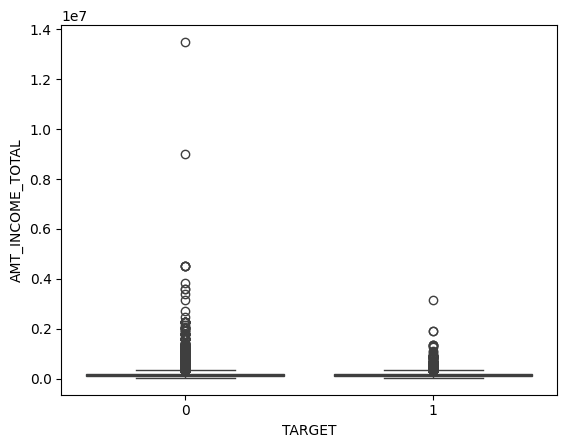

In [21]:

sns.boxplot(x=y_ml_train, y=X_ML_train['AMT_INCOME_TOTAL'])

In [22]:
X_ML_train['INCOME_LOG'] = np.log1p(X_ML_train['AMT_INCOME_TOTAL'])
X_ML_test['INCOME_LOG']  = np.log1p(X_ML_test['AMT_INCOME_TOTAL'])

<Axes: xlabel='TARGET', ylabel='INCOME_LOG'>

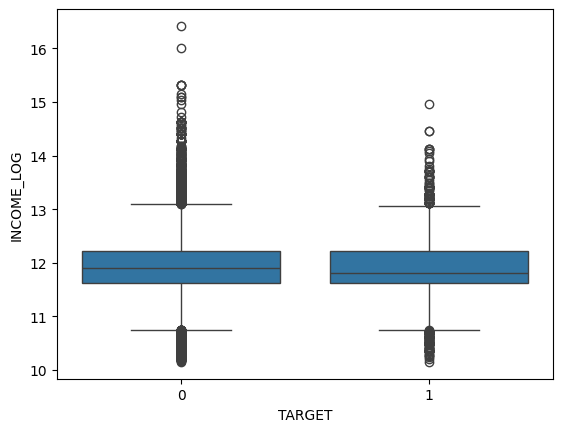

In [23]:
sns.boxplot(x=y_ml_train, y=X_ML_train['INCOME_LOG'])

In [24]:
# this will only give meaningfull skewed fetaures , it wont give binary fatures
numeric_df = X_ML_train.select_dtypes(include='number')

non_binary = numeric_df.loc[:, numeric_df.nunique() > 2]
skew_features = non_binary.skew()
skew_features = skew_features[skew_features > 1].sort_values(ascending=False)

print(skew_features)


AMT_REQ_CREDIT_BUREAU_QRT     144.620962
AMT_REQ_CREDIT_BUREAU_DAY      26.988146
NONLIVINGAPARTMENTS_MODE       16.138415
AMT_INCOME_TOTAL               15.740859
NONLIVINGAPARTMENTS_MEDI       15.577772
NONLIVINGAPARTMENTS_AVG        15.425724
OBS_30_CNT_SOCIAL_CIRCLE       14.300496
AMT_REQ_CREDIT_BUREAU_HOUR     14.288533
OBS_60_CNT_SOCIAL_CIRCLE       14.214606
INCOME_PER_PERSON               9.592166
AMT_REQ_CREDIT_BUREAU_WEEK      9.412058
AMT_REQ_CREDIT_BUREAU_MON       7.828124
NONLIVINGAREA_AVG               6.527376
NONLIVINGAREA_MEDI              6.477313
NONLIVINGAREA_MODE              6.469599
COMMONAREA_MODE                 5.598538
DEF_30_CNT_SOCIAL_CIRCLE        5.495088
DEF_60_CNT_SOCIAL_CIRCLE        5.479799
COMMONAREA_AVG                  5.446637
COMMONAREA_MEDI                 5.397583
LANDAREA_AVG                    4.446891
LANDAREA_MODE                   4.364674
LANDAREA_MEDI                   4.357916
BASEMENTAREA_AVG                3.553140
BASEMENTAREA_MED

In [25]:
skew_cols = skew_features[skew_features > 3].index

X_ML_train[skew_cols] = np.log1p(X_ML_train[skew_cols])
X_ML_test[skew_cols] = np.log1p(X_ML_test[skew_cols])

In [56]:
# join() is used to combine two datasets (DataFrames or Series) together based on their index.

# corr = X_ML_train.join(y_train).corr() --> join() is simply adding the TARGET column back to the feature dataset so you can compute correlations with it.

# Why we need join() --> Your data is currently separated like this:   X_ML_train                          y_train
#                                                                      AMT_CREDIT
#                                                                     AMT_INCOME_TOTAL                     TARGET
#                                                                     AMT_ANNUITY
#                                                                     ... 
# What join() actually does                                                                                            
#                       X_ML_train.join(y_train)   creates something like:                                          
#                                                 | AMT_CREDIT | AMT_INCOME_TOTAL | ... | TARGET |
#                                                 | ---------- | ---------------- | --- | ------ |
#                                                 | 100000     | 120000           | ... | 0      |
#                                                 | 200000     | 180000           | ... | 1      |
#                                                 | 150000     | 90000            | ... | 0      |
              

In [26]:

X_ML_train = pd.get_dummies(X_ML_train, drop_first=True)
X_ML_test  = pd.get_dummies(X_ML_test, drop_first=True)

# this will align the columns order, otherwise i can get an error when i training the model
X_ML_train, X_ML_test = X_ML_train.align(X_ML_test, join='left', axis=1, fill_value=0)

Your correlation matrix (corr) looks like this conceptually:
| Feature          | TARGET |
| ---------------- | ------ |
| AMT_CREDIT       | 0.12   |
| AMT_INCOME_TOTAL | -0.08  |
| DAYS_BIRTH       | -0.19  |
| EXT_SOURCE_3     | -0.28  |

corr['TARGET'] --> extracts the correlation of every feature with TARGET
abs() --> ignoring the negative and make them postive to take absulute vallues and that way ignoring the direction

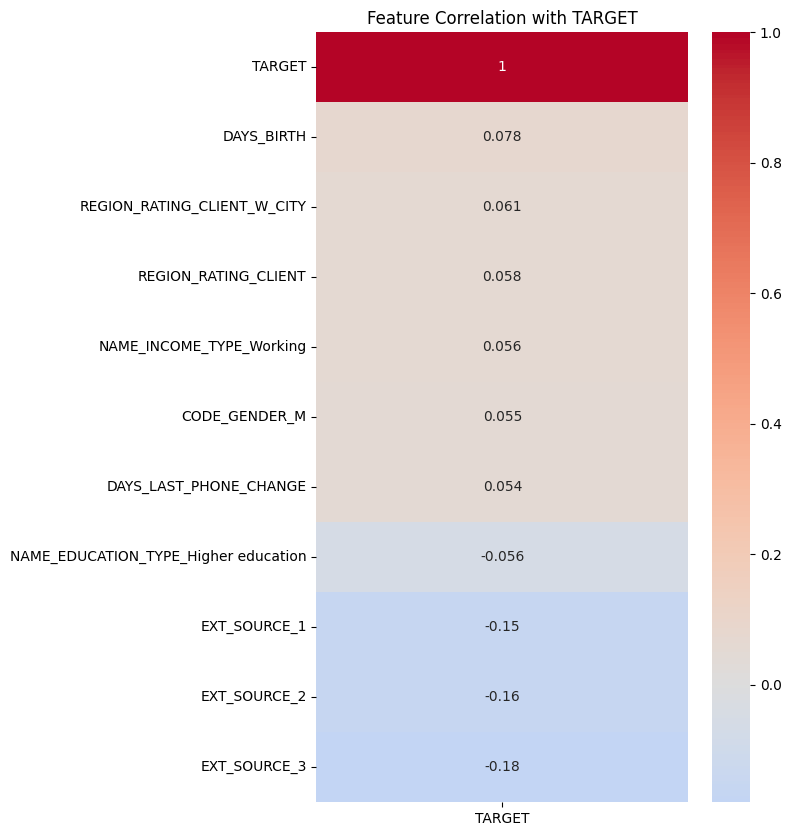

In [27]:
# combine features and target and check corelation relationship
corr = X_ML_train.join(y_ml_train).corr()

top_features = corr['TARGET'].abs().drop('TARGET').sort_values(ascending=False).head(10).index

df_corr = X_ML_train[top_features].join(y_ml_train)
# compute correlation, features to target
corr_target = df_corr.corr()[['TARGET']].sort_values(by='TARGET', ascending=False)
# | Feature      | TARGET |
# | ------------ | ------ |
# | EXT_SOURCE_3 | 0.42   |
# | EXT_SOURCE_2 | 0.39   |
# | DAYS_BIRTH   | 0.31   |
# | EXT_SOURCE_1 | 0.28   |


plt.figure(figsize=(6,10))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation with TARGET") # Feature → TARGET --> find strongest predictors

plt.show()

In [28]:
strong_features = corr_target[
    corr_target['TARGET'] > 0.05
].index.drop('TARGET') # index giving the only features name not values
strong_features

Index(['DAYS_BIRTH', 'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT',
       'NAME_INCOME_TYPE_Working', 'CODE_GENDER_M', 'DAYS_LAST_PHONE_CHANGE'],
      dtype='object')

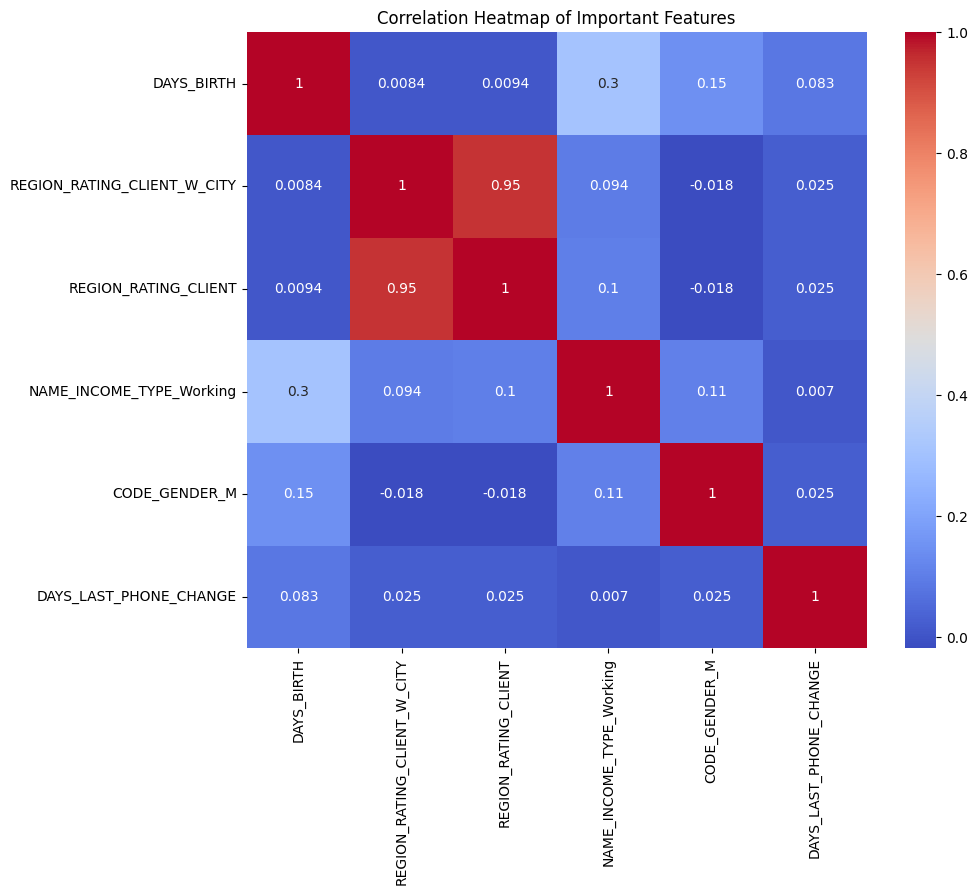

In [29]:
# combine features and target and check corelation relationship
# corr = X_ML_train.join(y_ml_train).corr()

# select top features correlated with target and remove the target because
#  it will always be "1" for itself so i will only get target corelation by itself
# i do "corr['TARGET'], so i can see only correlation between target and other features ,if i hadn't do it ,
#  i would get all features realtinship between each other
# corr['TARGET'] --> you extract the column that shows how every variable correlates with TARGET.(correlation(feature, TARGET))
# top_features = strong_features['TARGET'].abs().drop('TARGET').sort_values(ascending=False).index

plt.figure(figsize=(10,8))
# Visualize relationships --> Does NOT use TARGET
sns.heatmap(X_ML_train[strong_features].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap of Important Features") # FEATURS T0 FEATURES --> HELP TO find and can be removed redundant predictors
plt.show()

In [30]:
print("NaN count:", X_ML_train.isna().sum().sum())

NaN count: 6713773


In [31]:
imputer = SimpleImputer(strategy='median')

X_ML_train = pd.DataFrame(
    imputer.fit_transform(X_ML_train),
    columns=X_ML_train.columns,
    index=X_ML_train.index
)

X_ML_test = pd.DataFrame(
    imputer.transform(X_ML_test),
    columns=X_ML_test.columns,
    index=X_ML_test.index
)

In [32]:
# scaling the fetaures
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_ML_train)
X_test_scaled = scaler.transform(X_ML_test)

In [33]:
model_ml = LogisticRegression(max_iter=1000)

model_ml.fit(X_train_scaled, y_ml_train)

LogisticRegression(max_iter=1000)

In [34]:
# predicted classes
y_pred_ml = model_ml.predict(X_test_scaled)

# predicted probabilities
y_pred_prob_ml = model_ml.predict_proba(X_test_scaled)[:,1]

accuracy_ml = accuracy_score(y_ml_test, y_pred_ml)

print("Accuracy of ML:", accuracy_ml)

Accuracy of ML: 0.9192884899923581


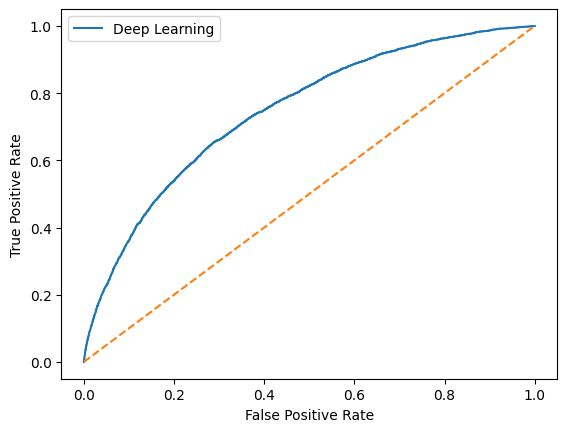

In [35]:
fpr, tpr, _ = roc_curve(y_ml_test, y_pred_prob_ml)

plt.plot(fpr, tpr, label="Deep Learning")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 3.1.2.DL 

In [3]:
df_dp = df.copy()
df_dp.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
df_dp= pd.get_dummies(df_dp, drop_first=False)
df_dp.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business

In [5]:

X_dl = df_dp.drop(columns=["TARGET"]).copy()
y_dl = df_dp["TARGET"].copy()

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42,
    stratify=y_dl
)



In [6]:
# adding new features as ratio of between each other , so model can learn more
X_train_ml["CREDIT_INCOME_RATIO"]  = X_train_ml["AMT_CREDIT"] / (X_train_ml["AMT_INCOME_TOTAL"] + 1)
X_train_ml["ANNUITY_INCOME_RATIO"] = X_train_ml["AMT_ANNUITY"] / (X_train_ml["AMT_INCOME_TOTAL"] + 1)
X_train_ml["CREDIT_TERM"]          = X_train_ml["AMT_CREDIT"] / (X_train_ml["AMT_ANNUITY"] + 1)
X_train_ml["DAYS_EMPLOYED_RATIO"]  = X_train_ml["DAYS_EMPLOYED"] / (X_train_ml["DAYS_BIRTH"] + 1)

# same for testing data
X_test_ml["CREDIT_INCOME_RATIO"]  = X_test_ml["AMT_CREDIT"] / (X_test_ml["AMT_INCOME_TOTAL"] + 1)
X_test_ml["ANNUITY_INCOME_RATIO"] = X_test_ml["AMT_ANNUITY"] / (X_test_ml["AMT_INCOME_TOTAL"] + 1)
X_test_ml["CREDIT_TERM"]          = X_test_ml["AMT_CREDIT"] / (X_test_ml["AMT_ANNUITY"] + 1)
X_test_ml["DAYS_EMPLOYED_RATIO"]  = X_test_ml["DAYS_EMPLOYED"] / (X_test_ml["DAYS_BIRTH"] + 1)


In [7]:

print("After split:", X_train_ml.shape, y_train_ml.shape)

After split: (246008, 249) (246008,)


In [8]:
# Step 1: Separate numeric and categorical columns
num_cols = X_train_ml.select_dtypes(include=["number"]).columns
cat_cols = X_train_ml.select_dtypes(exclude=["number"]).columns

In [9]:
# What degree=2, interaction_only=True Means
# Given features: [A, B, C]

# degree=2 would normally give you:
# A, B, C, A², B², C², A×B, A×C, B×C

# interaction_only=True removes the squared terms:
# A², B², C²  ← removed
# Only keeps: A×B, A×C, B×C  ← just the pairs

In [10]:
#  Impute NUMERIC with median
num_imputer = SimpleImputer(strategy="median")
X_train_ml[num_cols] = num_imputer.fit_transform(X_train_ml[num_cols])


In [11]:
# After missingness
print("After missingness:", X_train_ml.shape)

After missingness: (246008, 249)


In [12]:
#  use transform()  on test data!
X_test_ml[num_cols] = num_imputer.transform(X_test_ml[num_cols])

In [13]:

# Reset BEFORE poly, not after!
X_train_ml = X_train_ml.reset_index(drop=True)
X_test_ml  = X_test_ml.reset_index(drop=True)

# pick your most important numeric columns base on corelation
top_num_cols = [
    "DAYS_BIRTH",
    "DAYS_LAST_PHONE_CHANGE",
    "REGION_RATING_CLIENT_W_CITY",
    "REGION_RATING_CLIENT"
]

#  PolynomialFeatures creates all pair combinations
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# Computes the multiplications
interactions_train = poly.fit_transform(X_train_ml[top_num_cols])
# Now you have: age×income, age×loan_amount, income×loan_amount

# Wrap in a DataFrame with proper column names
interaction_df = pd.DataFrame(interactions_train, columns=poly.get_feature_names_out(),
                                index=X_train_ml.index)  # ← match index!)

# Glue these new columns onto your original X
X_train_ml = pd.concat([X_train_ml, interaction_df], axis=1).reset_index(drop=True)

## Simple Visual Summary
# BEFORE:                      AFTER:
# | age | income | loan |      | age | income | loan | age×income | age×loan | income×loan |
# |-----|--------|------|      |-----|--------|------|------------|----------|-------------|
# | 25  | 50000  | 10k  |  →   | 25  | 50000  | 10k  | 1,250,000  | 250,000  | 500,000,000 |
# | 35  | 80000  | 20k  |      | 35  | 80000  | 20k  | 2,800,000  | 700,000  | 1.6 billion |

In [14]:
interactions_test = poly.transform(X_test_ml[top_num_cols])
# Wrap in a DataFrame with proper column names
interaction_df_test = pd.DataFrame(interactions_test, columns=poly.get_feature_names_out(),
                                index=X_test_ml.index)  # ← match index!)


# Glue these new columns onto your original X
X_test_ml = pd.concat([X_test_ml, interaction_df_test], axis=1).reset_index(drop=True)


In [15]:
# After polynomial
print("After poly:", X_train_ml.shape)

After poly: (246008, 259)


In [16]:
# Log transform
skewed_cols = X_train_ml.select_dtypes(include="number").apply(lambda c: c.skew())
high_skew = skewed_cols[skewed_cols > 1.5].index

for col in high_skew:
    X_train_ml[f"{col}_log"] = np.log1p(X_train_ml[col].clip(lower=0))
    X_test_ml[f"{col}_log"]  = np.log1p(X_test_ml[col].clip(lower=0))

# Sort both the same way → same order guaranteed!
X_train_ml = X_train_ml.sort_index(axis=1)
X_test_ml  = X_test_ml.sort_index(axis=1)

In [17]:
# After log
print("After log:", X_train_ml.shape)

After log: (246008, 337)


In [18]:

# scaling
scaler = StandardScaler(with_mean=False)
X_train_s = scaler.fit_transform(X_train_ml)
X_test_s  = scaler.transform(X_test_ml)  

In [19]:
# Before residual block:
# residual = x  # saves current values e.g. [0.5, 0.3, 0.8]

# After going through Dense layers:
# x = [0.4, 0.2, 0.6]  # values changed

# Add them together:
# x = layers.Add()([x, residual])
# x = [0.4+0.5, 0.2+0.3, 0.6+0.8]
# x = [0.9, 0.5, 1.4]  # ← combined information

In [20]:
inputs = keras.Input(shape=(X_train_s.shape[1],))

# First block
x = layers.Dense(512, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Residual block
residual = x
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Add()([x, residual])  # ← skip connection!

# Continue
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.1)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)


In [21]:
# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_ml),
    y=y_train_ml
)
weight_dict = dict(zip(np.unique(y_train_ml), class_weights))

In [22]:
print(X_train_s.shape)    # how many rows?
print(y_train_ml.shape)   # how many rows?

(246008, 337)
(246008,)


In [23]:
history = model.fit(
    X_train_s, y_train_ml,     
    validation_split=0.2,
    epochs=20,
    class_weight=weight_dict,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20


2026-03-10 03:55:42.562148: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 265294488 exceeds 10% of free system memory.


3076/3076 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - auc: 0.7017 - loss: 0.6352 - val_auc: 0.7291 - val_loss: 0.4910
Epoch 2/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - auc: 0.7277 - loss: 0.6101 - val_auc: 0.7397 - val_loss: 0.7505
Epoch 3/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 62s 20ms/step - auc: 0.7312 - loss: 0.6069 - val_auc: 0.7427 - val_loss: 0.6102
Epoch 4/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step - auc: 0.7354 - loss: 0.6038 - val_auc: 0.7442 - val_loss: 0.7233
Epoch 5/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 60s 19ms/step - auc: 0.7377 - loss: 0.6017 - val_auc: 0.7452 - val_loss: 0.5518
Epoch 6/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - auc: 0.7405 - loss: 0.5992 - val_auc: 0.7472 - val_loss: 0.6246
Epoch 7/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 58s 19ms/step - auc: 0.7417 - loss: 0.5985 - val_auc: 0.7453 - val_loss: 0.6466
Epoch 8/20
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 56s 18ms/step - auc: 0.7424 - loss: 0.5975 - val_auc: 0.7452 - val_loss: 0.7369
Epoch 9/20
3076/3076 ━━━━━━━━━━━━━━

In [24]:
y_pred_p = model.predict(X_test_s).ravel()   


1922/1922 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [26]:
fpr_dl, tpr_dl, thresholds = roc_curve(y_test_ml, y_pred_p) 
     
best_thresh = thresholds[np.argmax(tpr_dl - fpr_dl)]
print(f"Best threshold: {best_thresh:.3f}")

Best threshold: 0.542


In [27]:
y_pred = (y_pred_p > 0.5).astype(int)

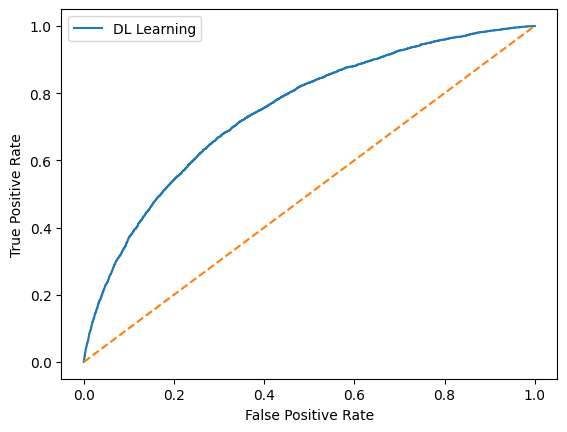

In [28]:

plt.plot(fpr_dl, tpr_dl, label="DL Learning")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()